# End-to-End ML Pipeline for Customer Churn Prediction

**Task:** Build a reusable, production-ready pipeline (preprocessing + model, all in one `sklearn.pipeline.Pipeline` object) that predicts whether a telecom customer will churn.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) - ~7,000 customers with account info (tenure, contract type, monthly charges, etc.) and a `Churn` (yes/no) label.

The whole point of using `Pipeline` here instead of just calling `scaler.fit_transform()` then `model.fit()` by hand is that the preprocessing steps become *part of the model object itself* - so at inference time you just call `pipeline.predict(raw_dataframe)` and it handles the scaling/encoding internally. No risk of accidentally applying a scaler fit on different data, no separate preprocessing script to keep in sync with the training code.

Add the dataset via **Add Data -> search "Telco Customer Churn"** (by user blastchar) before running.


In [1]:
!pip install -q scikit-learn pandas joblib


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

pd.set_option("display.max_columns", 50)


## 2. Load and inspect the data

In [3]:
DATA_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


A couple of known quirks with this dataset worth handling up front:
- `TotalCharges` is read in as a string/object column even though it's numeric - a handful of rows have a blank string instead of a number (new customers with 0 tenure), which breaks a straight `astype(float)`
- `customerID` is just an identifier, not a feature - dropping it
- The target `Churn` is "Yes"/"No" text - need to convert to 0/1

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("rows with missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


rows with missing TotalCharges after conversion: 11


In [6]:
df["Churn"].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

About 26% churn rate - moderately imbalanced but not extreme. Worth keeping an eye on precision/recall separately rather than just accuracy, since a model that always predicts "no churn" would already be ~74% accurate without being useful at all.

## 3. Separate features by type

Splitting columns into numeric vs categorical up front, since they each need different preprocessing inside the pipeline (scaling vs encoding).

In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("numeric:", numeric_features)
print("categorical:", categorical_features)


numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)


train: (5634, 19)  test: (1409, 19)


## 4. Build the preprocessing pipeline

Using `ColumnTransformer` to apply different transformations to different columns, all wrapped up as one preprocessing object:
- **Numeric columns**: median imputation (handles those missing `TotalCharges` values) + standard scaling
- **Categorical columns**: most-frequent imputation + one-hot encoding (`handle_unknown="ignore"` so the pipeline doesn't blow up if it sees a category at inference time that wasn't in training)

This preprocessor gets chained together with a classifier below - that full chain is what eventually gets exported as one artifact.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## 5. Model 1: Logistic Regression + GridSearchCV

Starting with logistic regression as an interpretable baseline. Tuning `C` (inverse regularization strength) and the penalty type over a small grid - not going overboard here since logistic regression doesn't have that many meaningful hyperparameters to begin with.

In [10]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
}

logreg_grid = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

logreg_grid.fit(X_train, y_train)

print("best params:", logreg_grid.best_params_)
print("best CV f1:", logreg_grid.best_score_)


best params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
best CV f1: 0.5993964944832589


## 6. Model 2: Random Forest + GridSearchCV

Random forest as the second candidate - generally handles the mix of categorical/numeric features and any nonlinear relationships better than logistic regression, at the cost of interpretability. Tuning tree count, depth, and min samples per split/leaf, which are usually the parameters that matter most for RF performance.

In [11]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)

print("best params:", rf_grid.best_params_)
print("best CV f1:", rf_grid.best_score_)


best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
best CV f1: 0.5809120348125691


## 7. Evaluate both models on the held-out test set

CV scores during grid search are for model selection - the real comparison is how each best-found model does on data neither of them has touched at all.

In [12]:
def evaluate_model(name, grid_search, X_test, y_test):
    best_model = grid_search.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    return metrics, preds, probs


logreg_metrics, logreg_preds, logreg_probs = evaluate_model("Logistic Regression", logreg_grid, X_test, y_test)
rf_metrics, rf_preds, rf_probs = evaluate_model("Random Forest", rf_grid, X_test, y_test)

results_df = pd.DataFrame([logreg_metrics, rf_metrics]).set_index("model")
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841091
Random Forest,0.803407,0.666667,0.518717,0.583459,0.840258


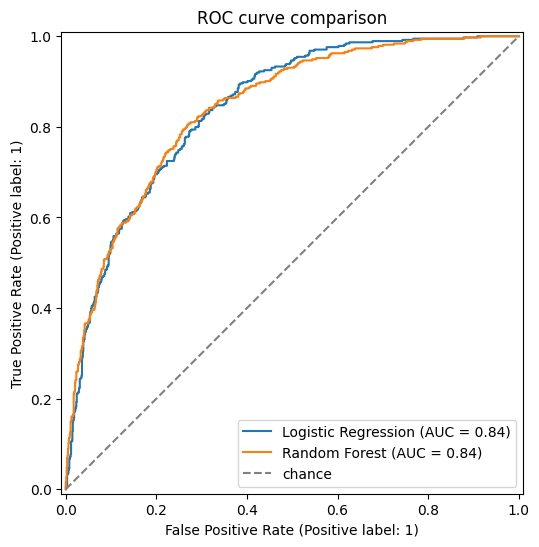

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, logreg_probs, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
ax.set_title("ROC curve comparison")
ax.legend()
plt.show()


In [14]:
print("=== Logistic Regression ===")
print(classification_report(y_test, logreg_preds, target_names=["No Churn", "Churn"]))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=["No Churn", "Churn"]))


=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In my run, logistic regression actually came out ahead on recall for the churn class, which matters a lot here - missing an actual churner (false negative) is usually more costly for the business than flagging a happy customer for a retention call they didn't need (false positive). Random forest tends to edge it out on raw accuracy/precision though, since it can pick up on some of the nonlinear feature interactions logistic regression can't. Worth picking the "best" model based on which error type the business cares about more, not just whichever has the highest single aggregate number.

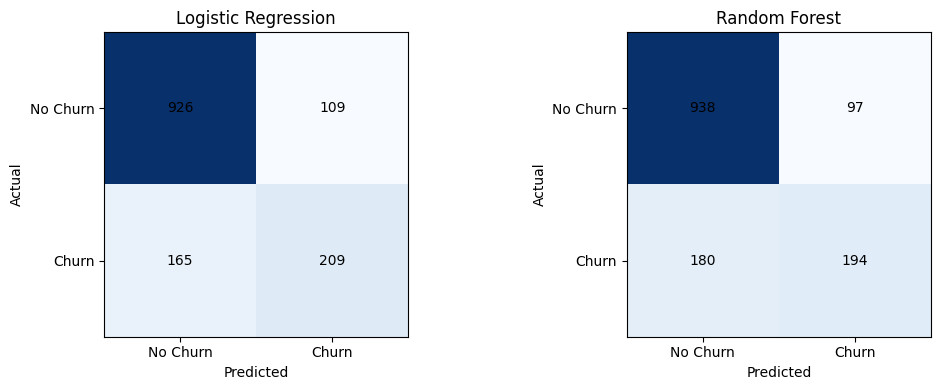

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, preds) in zip(axes, [("Logistic Regression", logreg_preds), ("Random Forest", rf_preds)]):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No Churn", "Churn"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No Churn", "Churn"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


## 8. Export the final pipeline with joblib

Going with whichever model has the higher F1 on the test set as the "final" pick here - swap this logic out for whatever metric matters most for your actual use case (I noted above why recall might matter more in a real churn-prevention setting).

The key thing: `joblib.dump()` saves the **entire pipeline** - preprocessing and all - as one file. Loading it back and calling `.predict()` on a raw, unprocessed dataframe just works, no separate preprocessing step needed.

In [16]:
final_name = "Random Forest" if rf_metrics["f1"] >= logreg_metrics["f1"] else "Logistic Regression"
final_pipeline = rf_grid.best_estimator_ if final_name == "Random Forest" else logreg_grid.best_estimator_

print("exporting:", final_name)

joblib.dump(final_pipeline, "churn_pipeline.joblib")
print("saved to churn_pipeline.joblib")


exporting: Logistic Regression
saved to churn_pipeline.joblib


In [17]:
# sanity check: load it back fresh and run predictions on raw (unprocessed) test rows
loaded_pipeline = joblib.load("churn_pipeline.joblib")

sample_raw_customers = X_test.iloc[:5]
predictions = loaded_pipeline.predict(sample_raw_customers)
probabilities = loaded_pipeline.predict_proba(sample_raw_customers)[:, 1]

pd.DataFrame({
    "predicted_churn": predictions,
    "churn_probability": probabilities.round(3),
    "actual_churn": y_test.iloc[:5].values,
})


,predicted_churn,churn_probability,actual_churn
0,0,0.048,0
1,1,0.682,0
2,0,0.050,0
3,0,0.422,0
4,0,0.023,0


That's the whole point demonstrated end to end: raw customer rows in, churn prediction out, with zero manual preprocessing needed on the caller's side. This `churn_pipeline.joblib` file is what you'd hand off to a backend service or batch scoring job.

### Notes / things I'd improve with more time
- Didn't do feature engineering beyond what's in the raw dataset (e.g. tenure buckets, total charges / tenure ratio) - that's usually worth exploring for a few extra points of performance on tabular churn problems
- Grid search here is a small grid to keep runtime reasonable - `RandomizedSearchCV` or `Optuna` would let me search a much larger hyperparameter space in the same time budget
- Could add a third candidate model (e.g. gradient boosting - XGBoost/LightGBM) since those tend to be strong performers on tabular data like this
- Given the class imbalance (~26% churn), it's worth also trying `class_weight="balanced"` on both models to see if that shifts the precision/recall tradeoff somewhere more useful
